# Imports 

In [1]:
import numpy as np 
import pandas as pd
from matplotlib.pyplot import subplots
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

# Load data

In [2]:
Boston = load_data("Boston")
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

----------------
**Dicionario**

|coluna|significado|
|:----|:-------|
|medv| preço mediano das casas em uma dada vizinhança|
|rmvar| numero medio de quartos por casa|
|lstat| percentual de vizinhos com baixa renda|

# Funcoes 

In [3]:
def abline(ax, b, m,  *args, **kwargs):
    """
    def abline(ax,m, b, *args, **kwargs):
    xlim = ax.get_xlim()
    ylim = [m* xlim[0] + b , m*xlim[1] + b ]

    ax.plot(xlim, ylim, *args, **kwargs)
    
    """

    xlim = ax.get_xlim()
    ylim = [m* xlim[0] + b , m*xlim[1] + b ]

    return ax.plot(xlim, ylim, *args, **kwargs)

# Simple linear regression


## Fit com OLS - metodo padrao**

In [4]:
# Variavel preditora: lstat
X = pd.DataFrame({'intercept': np.ones(Boston.shape[0]),
                  'lstat': Boston['lstat']})
X.head()

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94
4,1.0,5.33


In [5]:
# Variavel dependente
y = Boston['medv']
model = sm.OLS(y,X)
results  = model.fit()

In [6]:
summarize(results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


In [7]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           5.08e-88
Time:                        08:07:07   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
results.params

intercept    34.553841
lstat        -0.950049
dtype: float64

--------------------
**Usando classe MS do ISLP p/ aplicar transformacoes sobre as variaveis preditoras**

In [9]:
# * usando fit e transform - duas etapas
#   nesse caso, ele prepara o X, inserindo o intercepto
design = MS(['lstat'])
design = design.fit(Boston)
X = design.transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [10]:
# usando fit e transform - uma etapa
design = MS(['lstat'])
X  = design.fit_transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


## Obtendo predicoes

In [11]:
new_df = pd.DataFrame({'lstat':[5, 10, 15]})
new_df

,lstat
0,5
1,10
2,15


In [12]:
# usa o objeto design (uma instancia de MS(['lstat'])) para aplicar transformacoes a novos dados
newX = design.transform(new_df)
newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


In [13]:
# predicoes
new_predictions = results.get_prediction(newX)
new_predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

In [14]:
# intervalos de confianca
new_predictions.conf_int(alpha=0.05)

array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

In [15]:
# intervalos de predicao
new_predictions.conf_int(obs=True, alpha=0.05)

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

-------------

### Adicionando alguns plots sobre os resultados

**Valores reais vs curva regressao**

- abline() é uma funcao que recebe as medicoes reais de uma variavel preditora, mais o intercepto, e plota uma regressao linear



```python   
    def abline(ax, b, m,  *args, **kwargs):
        xlim = ax.get_xlim()
        ylim = [m* xlim[0] + b , m*xlim[1] + b ]

        return ax.plot(xlim, ylim, *args, **kwargs)
```



- na chamada, entao, essa funcao recebe 34 como intercepto, e -0.94 como slope, e constroi a curva

In [16]:
results.params[0], results.params[1]

/tmp/ipykernel_5978/3330065818.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[0], results.params[1]


(np.float64(34.55384087938308), np.float64(-0.9500493537579922))

/tmp/ipykernel_5978/235122426.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[0],
/tmp/ipykernel_5978/235122426.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[1],


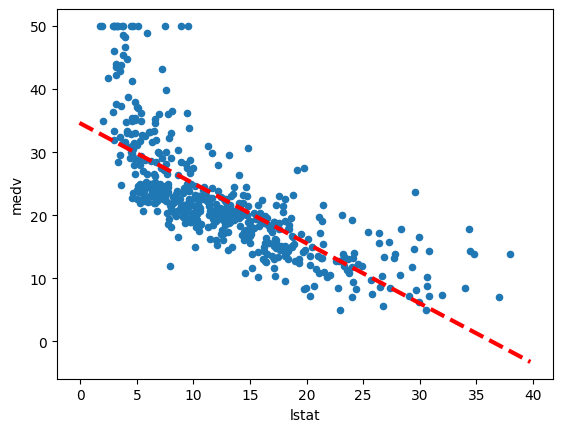

In [17]:
ax = Boston.plot.scatter('lstat', 'medv')

abline(ax,
       results.params[0], 
       results.params[1], 
       'r--', 
       linewidth=3)

-------------
**Fitted values vs residuos**

`ei = yi - yhat i`

*Regressao simples*: plota em relação a xi <br>
*Regressao multipla*: plota em relacao a yhat i


- util para identificar nao linearieade entre estimadores e variavel dependente

    *Idealmente nao é pra encontrarmos um padrao nesse grafico de erros. Encontrando, é um indicio de nao linearidade*
    
    >O que fazer? Transformações nao lineares dos preditoress: logX, root_square(X) e X² <br>

- util para identificar outliers, que podem impactar pouco OLS, porem podem influenciar:
    - RSE e p-values, que serao usados para computar intervalos de confiança
    - R²

- dado a dificuldade em definir quao grande deve ser um residuo para ser considerado um outlier, uma alternativa é plotar a *studentized residuals*: razao entre cada residuo e erro padrao estimado
    - se for acima de 3, possivelmente é um outlier

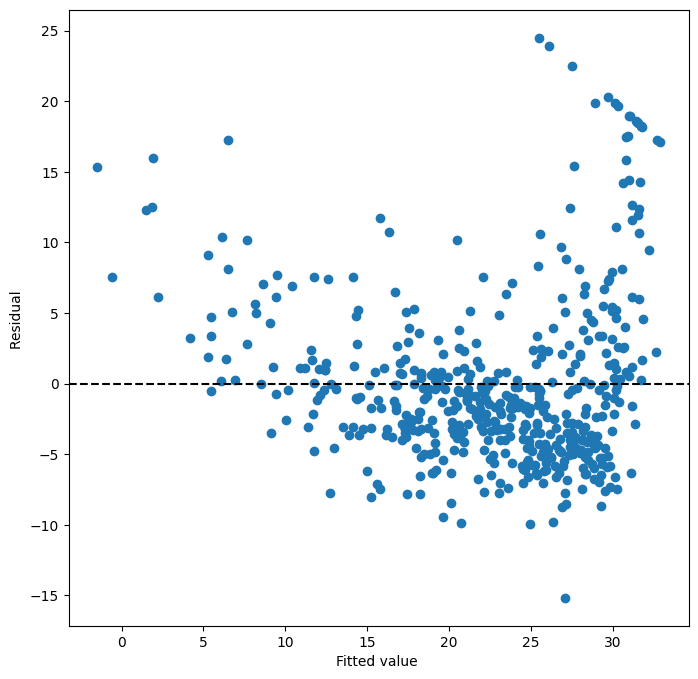

In [18]:
# Residuos
ax = subplots(figsize =(8 ,8))[1]
ax.scatter(results.fittedvalues , results.resid)
ax.set_xlabel('Fitted value ')
ax.set_ylabel('Residual ')
ax.axhline (0, c='k', ls='--')

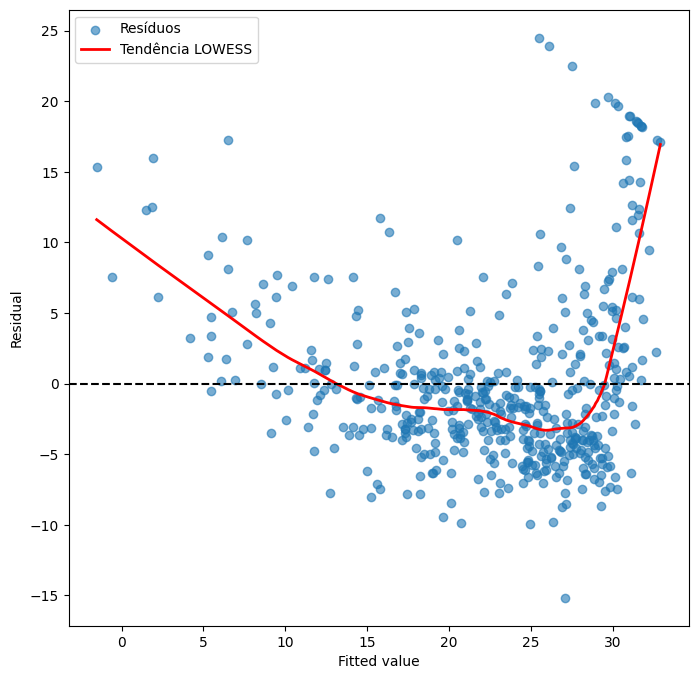

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# supondo que 'results' seja um modelo statsmodels
fitted = results.fittedvalues
resid = results.resid

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(fitted, resid, alpha=0.6, label='Resíduos')

# curva suavizada LOWESS
smooth = lowess(resid, fitted, frac=0.3)  # frac controla o grau de suavização
ax.plot(smooth[:, 0], smooth[:, 1], color='red', lw=2, label='Tendência LOWESS')

ax.axhline(0, color='k', ls='--')
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.legend()
plt.show()


--------------
**mais sobre os resultados**



- `get_influence()` da statsmodels, cria uma instancia a partir dos resultados da regressao e permite computar metricas de influencia 
- `.hat_matrix_diag`, por exemplo, retorna as "leverage metrics"
- `np.argmax()` retorna o indice do valor maximo dentro de um array 
- com isso, buscou-se qual valor tinha a maior "leverage statistic" dentro dos resultados

In [20]:
results.get_influence()

np.int64(374)

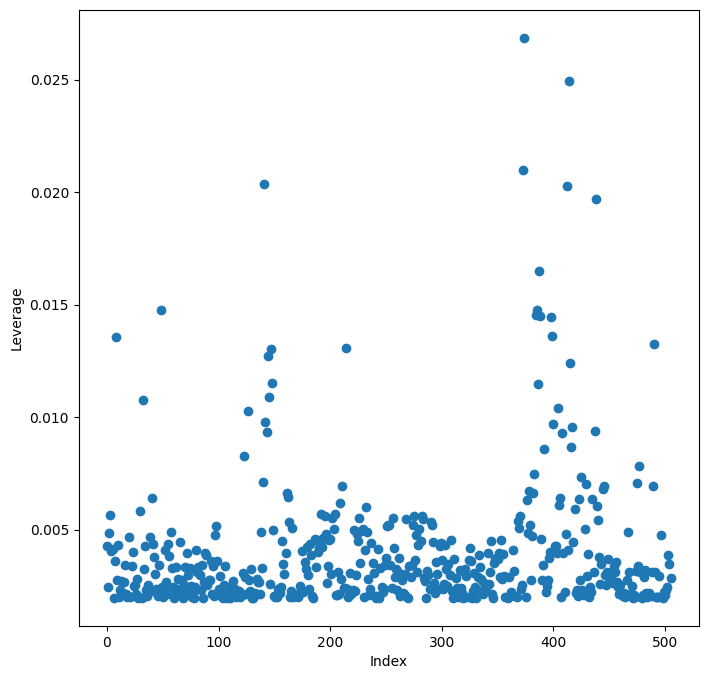

In [23]:
infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

In [28]:
infl.hat_matrix_diag.max(),


(np.float64(0.0268651665102835),)

In [27]:
infl.hat_matrix_diag.min()

np.float64(0.0019762912114917857)

# Multiple linear regression

**Exemplo com dois preditores**

In [32]:
X = MS(['lstat','age']).fit_transform(Boston)
lm1 = sm.OLS(y, X)
results1 = lm1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


----------------------------------
**Exemplo com dois preditores**

In [37]:
terms = Boston.columns.drop('medv')

In [40]:
X = MS(terms).fit_transform(Boston)
lm2 = sm.OLS(y,X)
results2 = lm2.fit()
summarize(results2)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


In [42]:
# util para saber os metodos contidos numa OLS
dir(results2)

['HC0_se',
 'HC1_se',
 'HC2_se',
 'HC3_se',
 '_HCCM',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abat_diagonal',
 '_cache',
 '_data_attr',
 '_data_in_cache',
 '_get_robustcov_results',
 '_get_wald_nonlinear',
 '_is_nested',
 '_transform_predict_exog',
 '_use_t',
 '_wexog_singular_values',
 'aic',
 'bic',
 'bse',
 'centered_tss',
 'compare_f_test',
 'compare_lm_test',
 'compare_lr_test',
 'condition_number',
 'conf_int',
 'conf_int_el',
 'cov_HC0',
 'cov_HC1',
 'cov_HC2',
 'cov_HC3',
 'cov_kwds',
 'cov_params',
 'cov_type',
 'df_model',
 'df_resid',
 'diagn',
 'eigenvals',
 'el_test',
 'ess',
 'f_pvalue',
 'f_test',
 'fittedvalues',
 'fvalue',
 '

In [ ]:
# R²
results2.rsquared

np.float64(0.7343070437613076)

In [ ]:
# RSE - estimador da variancia dos parametros da regressao
np.sqrt(results2.scale)

np.float64(4.798034335596367)

---------------
**VIF - Variation Inflaction Factor**

> Lembre-se: 
- mensura a multicolinearidade entre os preditores
- "~"1" ausencia de multicolinearidade
- ">5" colinearidade detectada 

> O que fazer se tiver multicolinearidade? 
- exclui a variavel problematica OU
- combina as duas variavies colineares em uma unica variavel composta

In [ ]:
# VIF - exclui o intercepto
vals = [VIF (X,i) for i in range (1, X.shape[1])]
vif = pd.DataFrame({'vif':vals}, index=X.columns[1:])
vif 

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


------------------
**Termos de interacao**

In [55]:
X = MS(['lstat','age',('lstat','age')]).fit_transform(Boston)
lm3 = sm.OLS(y,X)
results3 = lm3.fit()
summarize(results3)


,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


---------------
**Transformações nao lineares dos preditores**

In [57]:
X = MS([poly('lstat', degree=2),'age']).fit_transform(Boston)
model4 = sm.OLS(y, X)
results4 = model4.fit()
summarize(results4)


,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


In [59]:
anova_lm(results1, results4)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


- abaixo, nao há um padrao na distribuição dos y_pred em relação aos erros (y_real - y_pred)
- com isso, entende-se que houve uma melhora na aderencia dos dados a esse modelo quadratico 

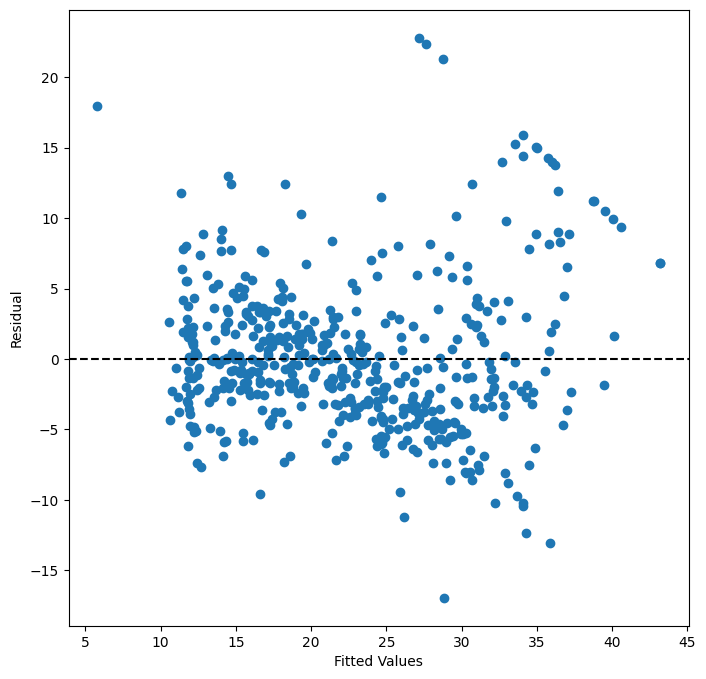

In [63]:
ax= subplots(figsize=(8,8))[1]
ax.scatter(results4.fittedvalues, results4.resid)
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residual")
ax.axhline(0, c='k', ls='--')